In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv

In [2]:
#Open the oscilloscope csv file
with open("SCOPES\\mlii_arritmia_cut_HIGH_01.csv") as fh:
    creader = csv.reader(fh)
    next(creader) #skip header row 1
    next(creader) #skip header row 2

    t = []
    v = []

    for l in creader:
        #keep only the rows which have a voltage value
        if len(l) > 1 and l[1].strip():
            t.append(float(l[0]))
            v.append(float(l[1]))

print("Done")

Done


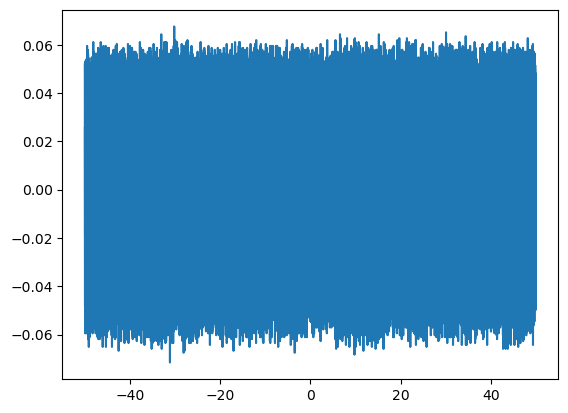

In [3]:
plt.plot(t,v)

In [4]:
import glob
import csv
import numpy as np

N = 64024  #minimum length among all captures

def read_voltage(path):
    #read voltage column from a scope CSV file
    with open(path) as fh:
        creader = csv.reader(fh)
        next(creader) #skip header row 1
        next(creader) #skip header row 2
        v = []
        for l in creader:
            if len(l) > 1 and l[1].strip():
                v.append(float(l[1]))
    return np.array(v)

files = glob.glob("CLOCK GATING\\SCOPES\\*.csv")

results = {}

for file in files:
    v = read_voltage(file)
    v_cut = v[:N] #truncate to common length N
    sum_cut = np.sum(v_cut**2) #sum of v^2 truncated
    mean_cut = np.mean(v_cut**2) #mean of v^2 truncated
    results[file] = {
        "sum": sum_cut,
        "mean": mean_cut
    }

for file, values in results.items():
    print(f"{file}  sum={values['sum']:.4f}  mean={values['mean']:.6f}")

CLOCK GATING\SCOPES\JD3K_CG_scope_6.csv  sum=5.0833  mean=0.000079
CLOCK GATING\SCOPES\JD3K_CG_scope_7.csv  sum=5.0659  mean=0.000079
CLOCK GATING\SCOPES\JD3K_CG_scope_8.csv  sum=5.1057  mean=0.000080
CLOCK GATING\SCOPES\LK27_CG_scope_09.csv  sum=5.0385  mean=0.000079
CLOCK GATING\SCOPES\LK27_CG_scope_10.csv  sum=5.0658  mean=0.000079
CLOCK GATING\SCOPES\LK27_CG_scope_11.csv  sum=5.0981  mean=0.000080
CLOCK GATING\SCOPES\MLII_ARRITMIA_CG_scope_15.csv  sum=5.0870  mean=0.000079
CLOCK GATING\SCOPES\MLII_ARRITMIA_CG_scope_16.csv  sum=5.0791  mean=0.000079
CLOCK GATING\SCOPES\MLII_ARRITMIA_CG_scope_17.csv  sum=5.1018  mean=0.000080
CLOCK GATING\SCOPES\MLII_CG_scope_12.csv  sum=5.0288  mean=0.000079
CLOCK GATING\SCOPES\MLII_CG_scope_13.csv  sum=5.0104  mean=0.000078
CLOCK GATING\SCOPES\MLII_CG_scope_14.csv  sum=5.0438  mean=0.000079
